# Project description

This project focuses on developing a machine learning model to classify patients based on their risk of Alzheimer's disease. The dataset contains various features such as demographic information, medical history, lifestyle factors, and cognitive assessments. The goal is to predict the binary diagnosis (0 = no Alzheimer's, 1 = Alzheimer's) using supervised learning techniques.

In [7]:
import pandas as pd
import numpy as np
import itertools

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import f1_score, roc_auc_score
from sklearn.model_selection import learning_curve, validation_curve, train_test_split, KFold, StratifiedKFold, cross_val_score, GridSearchCV, RandomizedSearchCV, cross_validate, RepeatedStratifiedKFold
from sklearn.linear_model import Perceptron, LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import FunctionTransformer, StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.datasets import fetch_openml
from sklearn.ensemble import RandomForestClassifier

from scipy.stats import loguniform, beta, uniform

from mlxtend.feature_selection import SequentialFeatureSelector as SFS

from imblearn.over_sampling import SMOTE, RandomOverSampler
from imblearn.pipeline import Pipeline as IMBPipeline

import missingno as msno

import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

## Dataset description

Source: https://www.kaggle.com/datasets/rabieelkharoua/alzheimers-disease-dataset

This dataset contains extensive health information for 2,149 patients, each uniquely identified with IDs ranging from 4751 to 6900. The dataset includes demographic details, lifestyle factors, medical history, clinical measurements, cognitive and functional assessments, symptoms, and a diagnosis of Alzheimer's Disease.

1.Demographic Details
Age: The age of the patients ranges from 60 to 90 years.
Gender: Gender of the patients, where 0 represents Male and 1 represents Female.
Ethnicity: The ethnicity of the patients, coded as follows:
0: Caucasian
1: African American
2: Asian
3: Other
EducationLevel: The education level of the patients, coded as follows:
0: None
1: High School
2: Bachelor's
3: Higher
2.Lifestyle Factors
BMI: Body Mass Index of the patients, ranging from 15 to 40.
Smoking: Smoking status, where 0 indicates No and 1 indicates Yes.
AlcoholConsumption: Weekly alcohol consumption in units, ranging from 0 to 20.
PhysicalActivity: Weekly physical activity in hours, ranging from 0 to 10.
DietQuality: Diet quality score, ranging from 0 to 10.
SleepQuality: Sleep quality score, ranging from 4 to 10.
3.Medical History
FamilyHistoryAlzheimers: Family history of Alzheimer's Disease, where 0 indicates No and 1 indicates Yes.
CardiovascularDisease: Presence of cardiovascular disease, where 0 indicates No and 1 indicates Yes.
Diabetes: Presence of diabetes, where 0 indicates No and 1 indicates Yes.
Depression: Presence of depression, where 0 indicates No and 1 indicates Yes.
HeadInjury: History of head injury, where 0 indicates No and 1 indicates Yes.
Hypertension: Presence of hypertension, where 0 indicates No and 1 indicates Yes.
4.Clinical Measurements
SystolicBP: Systolic blood pressure, ranging from 90 to 180 mmHg.
DiastolicBP: Diastolic blood pressure, ranging from 60 to 120 mmHg.
CholesterolTotal: Total cholesterol levels, ranging from 150 to 300 mg/dL.
CholesterolLDL: Low-density lipoprotein cholesterol levels, ranging from 50 to 200 mg/dL.
CholesterolHDL: High-density lipoprotein cholesterol levels, ranging from 20 to 100 mg/dL.
CholesterolTriglycerides: Triglycerides levels, ranging from 50 to 400 mg/dL.
Cognitive and Functional Assessments
MMSE: Mini-Mental State Examination score, ranging from 0 to 30. Lower scores indicate cognitive impairment.
FunctionalAssessment: Functional assessment score, ranging from 0 to 10. Lower scores indicate greater impairment.
MemoryComplaints: Presence of memory complaints, where 0 indicates No and 1 indicates Yes.
BehavioralProblems: Presence of behavioral problems, where 0 indicates No and 1 indicates Yes.
ADL: Activities of Daily Living score, ranging from 0 to 10. Lower scores indicate greater impairment.
5.Symptoms
Confusion: Presence of confusion, where 0 indicates No and 1 indicates Yes.
Disorientation: Presence of disorientation, where 0 indicates No and 1 indicates Yes.
PersonalityChanges: Presence of personality changes, where 0 indicates No and 1 indicates Yes.
DifficultyCompletingTasks: Presence of difficulty completing tasks, where 0 indicates No and 1 indicates Yes.
Forgetfulness: Presence of forgetfulness, where 0 indicates No and 1 indicates Yes.
6.Diagnosis Information
Diagnosis: Diagnosis status for Alzheimer's Disease, where 0 indicates No and 1 indicates Yes.

In [8]:
df = pd.read_csv("/content/alzheimers_disease_data.csv", sep=';')
df

,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,SleepQuality,...,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis,DoctorInCharge
0,73,0,0,2,22.927749,0,13.297218,6.327112,1.347214,9.025679,...,0,0,1.725883,0,0,0,1,0,0,XXXConfid
1,89,0,0,0,26.827681,0,4.542524,7.619885,0.518767,7.151293,...,0,0,2.592424,0,0,0,0,1,0,XXXConfid
2,73,0,3,1,17.795882,0,19.555085,7.844988,1.826335,9.673574,...,0,0,7.119548,0,1,0,1,0,0,XXXConfid
3,74,1,0,1,33.800817,1,12.209266,8.428001,7.435604,8.392554,...,0,1,6.481226,0,0,0,0,0,0,XXXConfid
4,89,0,0,0,20.716974,0,18.454356,6.310461,0.795498,5.597238,...,0,0,0.014691,0,0,1,1,0,0,XXXConfid
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2144,61,0,0,1,39.121757,0,1.561126,4.049964,6.555306,7.535540,...,0,0,4.492838,1,0,0,0,0,1,XXXConfid
2145,75,0,0,2,17.857903,0,18.767261,1.360667,2.904662,8.555256,...,0,1,9.204952,0,0,0,0,0,1,XXXConfid
2146,77,0,0,1,15.476479,0,4.594670,9.886002,8.120025,5.769464,...,0,0,5.036334,0,0,0,0,0,1,XXXConfid
2147,78,1,3,1,15.299911,0,8.674505,6.354282,1.263427,8.322874,...,0,0,3.785399,0,0,0,0,1,1,XXXConfid


# Data preprocessing

## Examine for missing values

Before splitting the data, I've examined the dataset for missing values. I've computed the percentage of missing values in each feature. Features with a high proportion of missing values may be removed or imputed later depending on their importance.

In [9]:

target_column = "Diagnosis"
X = df.drop(columns=[target_column])
y = df[target_column]
print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
X.isnull().sum(axis=0)/X.shape[0]

Features shape: (2149, 33)
Target shape: (2149,)


,0
Age,0.0
Gender,0.0
Ethnicity,0.0
EducationLevel,0.0
BMI,0.0
Smoking,0.0
AlcoholConsumption,0.0
PhysicalActivity,0.0
DietQuality,0.0
SleepQuality,0.0


### No missing values, no need for further analysis or modifications.

### However I want to delate the column ethnicity.

I decided to remove the Ethnicity column from my dataset to prevent potential bias in model training and predictions. Since the dataset originates from a specific geographic region, it is likely that certain ethnic groups are underrepresented. This imbalance could lead the model to over-associate Alzheimer's risk with the most represented ethnic group, simply due to its frequency in the data. Including this feature might falsely inflate risk predictions for the majority group and unfairly underrepresent others. To promote fairness and avoid misleading associations, we exclude this variable from the analysis.

In [10]:
df = df.drop(columns=['Ethnicity'])

### I want to check if the colums "MemoryComplaints" and "Forgetfulness" are similar because they have similar definitions.

If the similiarity between them is more than 70% then I want to merge them together meaning if in either column there is a positive answer i mark in a separate column "Memory Issuues" a positive answer as well.

In [11]:
matches = (df['Forgetfulness'] == df['MemoryComplaints']).sum()
total = len(df)
similarity_percent = (matches / total) * 100

print(f"Similarity: {similarity_percent:.2f}%")

if similarity_percent > 70:
    df['Memory Issue'] = df.apply(
        lambda row: 1 if row['Forgetfulness'] == 1 or row['MemoryComplaints'] == 1 else 0,
        axis=1
    )
    df = df.drop(columns=['Forgetfulness', 'MemoryComplaints'])

Similarity: 61.33%


## Checking for class imbalance in column: Diagnosis

If the column is highly imbalanced I will consider techniques like stratified splitting or resampling.

In [12]:
diagnosis_counts = df['Diagnosis'].value_counts()
print("Class distribution in 'Diagnosis' column:")
print(diagnosis_counts)

if df['Diagnosis'].value_counts(normalize=True).max() > 0.99:
    print("Highly imbalanced data detected")
else:
    print("Class distribution is acceptable")

Class distribution in 'Diagnosis' column:
Diagnosis
0    1389
1     760
Name: count, dtype: int64
Class distribution is acceptable


Moderate imbalance.

## Scaling numerical features

In [13]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
df[numerical_cols] = scaler.fit_transform(df[numerical_cols])

print("Numerical features scaled using MinMaxScaler.")

Numerical features scaled using MinMaxScaler.


Scaling ensures features contribute equally to model training.

# Splitting data into training and test sets

Used stratified splitting to maintain the same diagnosis ratio in both sets and prevent bias.

In [14]:
from sklearn.model_selection import train_test_split

# Separate features and target
X = df.drop('Diagnosis', axis=1)
y = df['Diagnosis']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify = y, random_state=30, shuffle=True)

print("Data split into training and test sets.")
print(f"Training set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")

Data split into training and test sets.
Training set size: 1719 samples
Test set size: 430 samples


# Building machine learning pipeline

### Data transformation

In [15]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# Separate column types
numerical_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()

# Define transformation (no hyperparameters here)
final_transformation = ColumnTransformer([
    ('num', StandardScaler(), numerical_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
])


ColumnTransformer ensures proper preprocessing for different data types.

### Pipeline

Components:
Transformation (scaling + encoding)
Resampling (SMOTE for handling class imbalance)
Dimensionality Reduction (PCA to retain 80% variance)
Classifier (Perceptron as initial model)

In [16]:
from imblearn.pipeline import Pipeline as IMBPipeline
from imblearn.over_sampling import SMOTE
from sklearn.decomposition import PCA
from sklearn.linear_model import Perceptron

model_pipeline = IMBPipeline([
    ('transform', final_transformation),
    ('sampler', SMOTE()),
    ('dim_reduction', PCA(n_components=0.8)),
    ('classifier', Perceptron())
])
model_pipeline.fit(X_train,y_train)

Pipeline(steps=[('transform',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Age', 'Gender',
                                                   'EducationLevel', 'BMI',
                                                   'Smoking',
                                                   'AlcoholConsumption',
                                                   'PhysicalActivity',
                                                   'DietQuality',
                                                   'SleepQuality',
                                                   'FamilyHistoryAlzheimers',
                                                   'CardiovascularDisease',
                                                   'Diabetes', 'Depression',
                                                   'HeadInjury', 'Hypertension',
                                                   'SystolicBP', 'DiastolicBP',
                                                   'CholesterolTotal'...
                                                   'CholesterolHDL',
                                                   'CholesterolTriglycerides',
                                                   'MMSE',
                                                   'FunctionalAssessment',
                                                   'MemoryComplaints',
                                                   'BehavioralProblems', 'ADL',
                                                   'Confusion',
                                                   'Disorientation',
                                                   'PersonalityChanges',
                                                   'DifficultyCompletingTasks', ...]),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['DoctorInCharge'])])),
                ('sampler', SMOTE()), ('dim_reduction', PCA(n_components=0.8)),
                ('classifier', Perceptron())])

In [17]:
model_pipeline.predict(X_test)

array([1., 0., 0., 0., 1., 0., 1., 0., 0., 1., 1., 0., 0., 0., 0., 0., 0.,
       0., 0., 1., 1., 0., 0., 0., 0., 1., 1., 0., 0., 1., 1., 1., 0., 0.,
       1., 0., 1., 0., 1., 0., 1., 1., 1., 1., 0., 0., 1., 0., 1., 1., 0.,
       0., 0., 1., 1., 1., 1., 1., 0., 0., 0., 1., 1., 0., 1., 1., 1., 1.,
       1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
       0., 0., 1., 0., 0., 0., 0., 0., 1., 1., 1., 1., 1., 1., 1., 1., 0.,
       0., 0., 0., 0., 0., 1., 0., 1., 0., 0., 1., 1., 0., 0., 0., 0., 0.,
       0., 0., 1., 0., 1., 1., 0., 0., 1., 1., 0., 0., 1., 1., 0., 0., 1.,
       0., 1., 1., 1., 0., 0., 0., 0., 0., 1., 0., 1., 0., 0., 1., 0., 0.,
       1., 0., 1., 1., 1., 1., 0., 0., 0., 1., 1., 1., 0., 1., 0., 1., 1.,
       1., 1., 0., 1., 1., 0., 0., 0., 1., 0., 1., 1., 1., 0., 1., 0., 0.,
       0., 1., 0., 0., 0., 1., 0., 0., 1., 0., 0., 1., 1., 0., 0., 1., 1.,
       1., 1., 0., 0., 1., 1., 0., 0., 0., 1., 1., 0., 0., 1., 0., 0., 0.,
       1., 1., 1., 1., 0.

# Model Selection and Tuning

### Configuration Options

In [18]:
from scipy.stats import uniform

sampler_configs = [
    {'sampler': [None]},
    {
        'sampler': [SMOTE()],
        'sampler__sampling_strategy': ['minority', 0.7, 0.9, 1.2]
    },
    {
        'sampler': [RandomOverSampler()],
        'sampler__sampling_strategy': ['minority', 0.7, 0.9, 1.2]
    }
]

dim_reduction_configs = [
    {'dim_reduction': [None]},
    {
        'dim_reduction': [PCA()],
        'dim_reduction__n_components': [0.5, 0.7, 0.9]
    },
    {'dim_reduction': [LDA()]},
    {
        'dim_reduction': [SFS(estimator=Perceptron(), cv=3, scoring='f1')],
        'dim_reduction__k_features': [5, 7, 10]
    }
]

classifier_configs = [
    {
        'classifier': [Perceptron()],
        'classifier__eta0': loguniform(0.001, 100),
        'classifier__max_iter': [50, 100, 200],
        'classifier__class_weight': [None, 'balanced']
    },
    {
        'classifier': [LogisticRegression(solver='saga')],
        'classifier__C': uniform(loc=0.1, scale=10),
        'classifier__penalty': ['l1', 'l2'],
        'classifier__class_weight': [None, 'balanced']
    },
    {
        'classifier': [KNeighborsClassifier()],
        'classifier__n_neighbors': [3, 5, 7, 9]
    },
    {
        'classifier': [RandomForestClassifier()],
        'classifier__n_estimators': [100, 150, 200, 250]
    }
]

# Generate all possible configurations
from itertools import product
all_configs = []
for sampler_config in sampler_configs:
    for dim_config in dim_reduction_configs:
        for clf_config in classifier_configs:
            config = {**sampler_config, **dim_config, **clf_config}
            all_configs.append(config)

In [19]:
for configuration in itertools.product(['a', 'b'], [1, 2, 3], ['Z', 'W', 'y']):
    print(configuration)

('a', 1, 'Z')
('a', 1, 'W')
('a', 1, 'y')
('a', 2, 'Z')
('a', 2, 'W')
('a', 2, 'y')
('a', 3, 'Z')
('a', 3, 'W')
('a', 3, 'y')
('b', 1, 'Z')
('b', 1, 'W')
('b', 1, 'y')
('b', 2, 'Z')
('b', 2, 'W')
('b', 2, 'y')
('b', 3, 'Z')
('b', 3, 'W')
('b', 3, 'y')


In [20]:
a = ({'a':1},{'b':2},{'c':3})
dict(itertools.chain(*(e.items() for e in a)))

{'a': 1, 'b': 2, 'c': 3}

In [21]:
all_configs = [dict(itertools.chain(*(e.items()
for e in configuration)))
for configuration in
itertools.product(sampler_configs,dim_reduction_configs,classifier_configs)]

f'Number of all possible configurations: {len(all_configs)}'


'Number of all possible configurations: 48'

In [22]:
all_configs[:2]

[{'sampler': [None],
  'dim_reduction': [None],
  'classifier': [Perceptron()],
  'classifier__eta0': <scipy.stats._distn_infrastructure.rv_continuous_frozen at 0x7cc4b87e34d0>,
  'classifier__max_iter': [50, 100, 200],
  'classifier__class_weight': [None, 'balanced']},
 {'sampler': [None],
  'dim_reduction': [None],
  'classifier': [LogisticRegression(solver='saga')],
  'classifier__C': <scipy.stats._distn_infrastructure.rv_continuous_frozen at 0x7cc4b85a60c0>,
  'classifier__penalty': ['l1', 'l2'],
  'classifier__class_weight': [None, 'balanced']}]

### Hyperparameter Tuning

-Tested 20 random combinations of these options
-Used 3-fold cross-validation
-Scored models using F1 score


In [23]:
rs = RandomizedSearchCV(
    model_pipeline,
    param_distributions=all_configs,
    n_iter=20,
    n_jobs=-1,
    cv=3,
    scoring='f1',
    random_state=42,
    verbose=3
)

rs.fit(X_train, y_train)

Fitting 3 folds for each of 20 candidates, totalling 60 fits


RandomizedSearchCV(cv=3,
                   estimator=Pipeline(steps=[('transform',
                                              ColumnTransformer(transformers=[('num',
                                                                               StandardScaler(),
                                                                               ['Age',
                                                                                'Gender',
                                                                                'EducationLevel',
                                                                                'BMI',
                                                                                'Smoking',
                                                                                'AlcoholConsumption',
                                                                                'PhysicalActivity',
                                                                                'DietQuality',
                                                                                'SleepQuality',
                                                                                'FamilyHistoryAlzheimers',
                                                                                'CardiovascularDisease',
                                                                                'Diabetes',
                                                                                'Depression',
                                                                                'HeadInjury',
                                                                                'Hypertension',
                                                                                'SystolicBP...
                                         'classifier__C': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7cc4b85a60c0>,
                                         'classifier__class_weight': [None,
                                                                      'balanced'],
                                         'classifier__penalty': ['l1', 'l2'],
                                         'dim_reduction': [SequentialFeatureSelector(cv=3,
                                                                                     estimator=Perceptron(),
                                                                                     scoring='f1')],
                                         'dim_reduction__k_features': [5, 7,
                                                                       10],
                                         'sampler': [SMOTE()],
                                         'sampler__sampling_strategy': ['minority',
                                                                        0.7,
                                                                        0.9,
                                                                        1.2]}, ...],
                   random_state=42, scoring='f1', verbose=3)

Logistic Regression performed best.

In [24]:
scores = cross_validate(
    rs,
    X_train,
    y_train,
    scoring='f1',
    cv=5,
    return_estimator=True,
    verbose=3
)

Fitting 3 folds for each of 20 candidates, totalling 60 fits
[CV] END ......................................., score=0.739 total time=  25.0s
Fitting 3 folds for each of 20 candidates, totalling 60 fits
[CV] END ......................................., score=0.772 total time=  24.7s
Fitting 3 folds for each of 20 candidates, totalling 60 fits
[CV] END ......................................., score=0.758 total time=  25.1s
Fitting 3 folds for each of 20 candidates, totalling 60 fits
[CV] END ......................................., score=0.755 total time=  25.7s
Fitting 3 folds for each of 20 candidates, totalling 60 fits
[CV] END ......................................., score=0.760 total time=  25.5s


[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed:  2.1min finished


###  Inspect the Best Models

In [25]:
for index, estimator in enumerate(scores['estimator']):
    print(f"\nFold {index+1} Best Model:")
    print("Sampler:", estimator.best_estimator_.named_steps['sampler'])
    print("Dim Reduction:", estimator.best_estimator_.named_steps['dim_reduction'])
    print("Classifier:", estimator.best_estimator_.named_steps['classifier'])
    print("Validation F1 Score:", scores['test_score'][index])
    print('-'*40)


Fold 1 Best Model:
Sampler: RandomOverSampler(sampling_strategy=0.9)
Dim Reduction: LinearDiscriminantAnalysis()
Classifier: LogisticRegression(C=np.float64(0.5666566321361542), class_weight='balanced',
                   solver='saga')
Validation F1 Score: 0.7392996108949417
----------------------------------------

Fold 2 Best Model:
Sampler: None
Dim Reduction: None
Classifier: LogisticRegression(C=np.float64(6.942330265121568), solver='saga')
Validation F1 Score: 0.7717842323651453
----------------------------------------

Fold 3 Best Model:
Sampler: None
Dim Reduction: None
Classifier: LogisticRegression(C=np.float64(7.319987722668247), class_weight='balanced',
                   solver='saga')
Validation F1 Score: 0.7575757575757576
----------------------------------------

Fold 4 Best Model:
Sampler: SMOTE(sampling_strategy=0.7)
Dim Reduction: None
Classifier: LogisticRegression(C=np.float64(7.851328233611145), class_weight='balanced',
                   solver='saga')
Validati

 Displayed the best sampler, dimensionality reducer, and classifier for each foled.

Shows validation F1 score for each fold.

### Evaluate on Test Set

In [26]:
for estimator in scores['estimator']:
    # Retrain on full training set
    estimator.best_estimator_.fit(X_train, y_train)

    # Predictions
    y_train_pred = estimator.best_estimator_.predict(X_train)
    y_test_pred = estimator.best_estimator_.predict(X_test)

    # Scores
    f1_train = f1_score(y_train, y_train_pred)
    f1_test = f1_score(y_test, y_test_pred)

    print(f"F1 on training set: {f1_train:.4f}, F1 on test set: {f1_test:.4f}")

F1 on training set: 0.7777, F1 on test set: 0.7638
F1 on training set: 0.7814, F1 on test set: 0.7752
F1 on training set: 0.7789, F1 on test set: 0.7638
F1 on training set: 0.7747, F1 on test set: 0.7566
F1 on training set: 0.7789, F1 on test set: 0.7638


### Refine the Best Model

In [27]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA

best_model_pipeline = IMBPipeline([
    ('transform', final_transformation),
    ('sampler', RandomOverSampler(sampling_strategy=0.9)),
    ('dim_reduction', LDA()),  # From your best params
    ('classifier', LogisticRegression(solver='saga', penalty='l2', class_weight='balanced'))
])

params = {
    'classifier__C': uniform(loc=0.1, scale=10)
}

rs_best = RandomizedSearchCV(
    estimator=best_model_pipeline,
    param_distributions=params,
    cv=RepeatedStratifiedKFold(n_splits=5, n_repeats=1),
    n_iter=20,
    scoring='f1'
)

rs_best.fit(X_train, y_train)

RandomizedSearchCV(cv=RepeatedStratifiedKFold(n_repeats=1, n_splits=5, random_state=None),
                   estimator=Pipeline(steps=[('transform',
                                              ColumnTransformer(transformers=[('num',
                                                                               StandardScaler(),
                                                                               ['Age',
                                                                                'Gender',
                                                                                'EducationLevel',
                                                                                'BMI',
                                                                                'Smoking',
                                                                                'AlcoholConsumption',
                                                                                'PhysicalActivity',
                                                                                'DietQuality',
                                                                                'SleepQuality',
                                                                                'FamilyHistoryAlzheimers',
                                                                                'CardiovascularDisease'...
                                                                               OneHotEncoder(handle_unknown='ignore'),
                                                                               ['DoctorInCharge'])])),
                                             ('sampler',
                                              RandomOverSampler(sampling_strategy=0.9)),
                                             ('dim_reduction',
                                              LinearDiscriminantAnalysis()),
                                             ('classifier',
                                              LogisticRegression(class_weight='balanced',
                                                                 solver='saga'))]),
                   n_iter=20,
                   param_distributions={'classifier__C': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7cc4b82d2e40>},
                   scoring='f1')

## Final model evaluation

### Learning curve

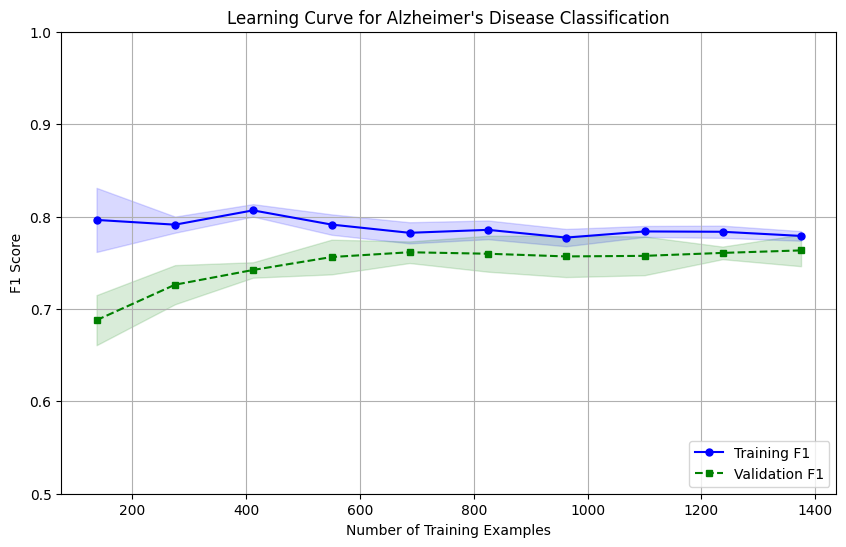

In [28]:
from sklearn.model_selection import learning_curve, validation_curve
import matplotlib.pyplot as plt
import numpy as np

train_sizes, train_scores, test_scores = learning_curve(
    rs_best.best_estimator_,
    X=X_train,
    y=y_train,
    train_sizes=[0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
    cv=5,
    n_jobs=-1,
    scoring='f1'
)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, color='blue', marker='o', markersize=5, label='Training F1')
plt.fill_between(train_sizes, train_mean + train_std, train_mean - train_std, alpha=0.15, color='blue')

plt.plot(train_sizes, test_mean, color='green', linestyle='--', marker='s', markersize=5, label='Validation F1')
plt.fill_between(train_sizes, test_mean + test_std, test_mean - test_std, alpha=0.15, color='green')

plt.title('Learning Curve for Alzheimer\'s Disease Classification')
plt.xlabel('Number of Training Examples')
plt.ylabel('F1 Score')
plt.legend(loc='lower right')
plt.grid()
plt.ylim([0.5, 1.0])
plt.show()

The training and validation curves converge smoothly without a large gap suggesting the model is not overfitting and generalizes well to unseen data.


### Validation curve

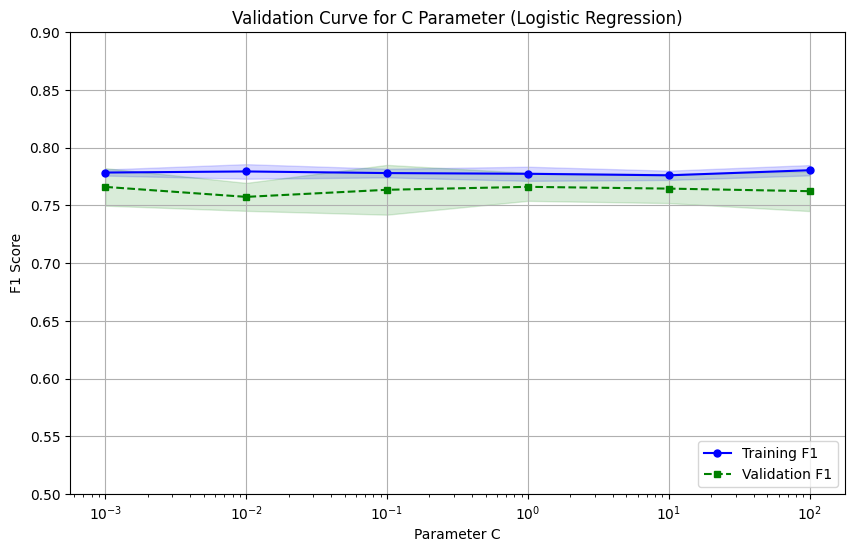

In [29]:
param_range = [0.001, 0.01, 0.1, 1, 10, 100]
train_scores, test_scores = validation_curve(
    rs_best.best_estimator_,
    X=X_train,
    y=y_train,
    param_name='classifier__C',
    param_range=param_range,
    cv=5,
    scoring='f1'
)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

plt.figure(figsize=(10, 6))
plt.plot(param_range, train_mean, color='blue', marker='o', markersize=5, label='Training F1')
plt.fill_between(param_range, train_mean + train_std, train_mean - train_std, alpha=0.15, color='blue')

plt.plot(param_range, test_mean, color='green', linestyle='--', marker='s', markersize=5, label='Validation F1')
plt.fill_between(param_range, test_mean + test_std, test_mean - test_std, alpha=0.15, color='green')

plt.title('Validation Curve for C Parameter (Logistic Regression)')
plt.xlabel('Parameter C')
plt.ylabel('F1 Score')
plt.legend(loc='lower right')
plt.grid()
plt.xscale('log')
plt.ylim([0.5, 0.9])
plt.show()

### Final model evaluation


Final Model Evaluation:
Best Parameters: {'classifier__C': np.float64(6.124247424070219)}

Classification Report:
              precision    recall  f1-score   support

         0.0       0.92      0.79      0.85       278
         1.0       0.69      0.87      0.77       152

    accuracy                           0.82       430
   macro avg       0.81      0.83      0.81       430
weighted avg       0.84      0.82      0.82       430


Confusion Matrix:
[[220  58]
 [ 20 132]]

F1 Score: 0.7719298245614035
Accuracy: 0.8186046511627907
ROC AUC: 0.9083680424081787


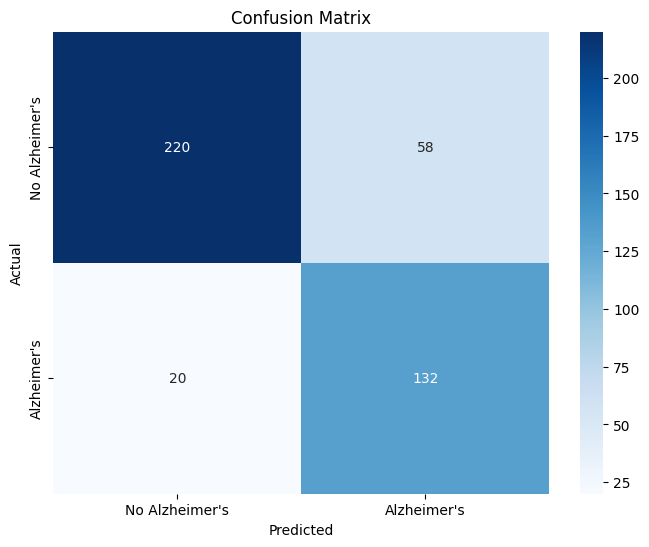

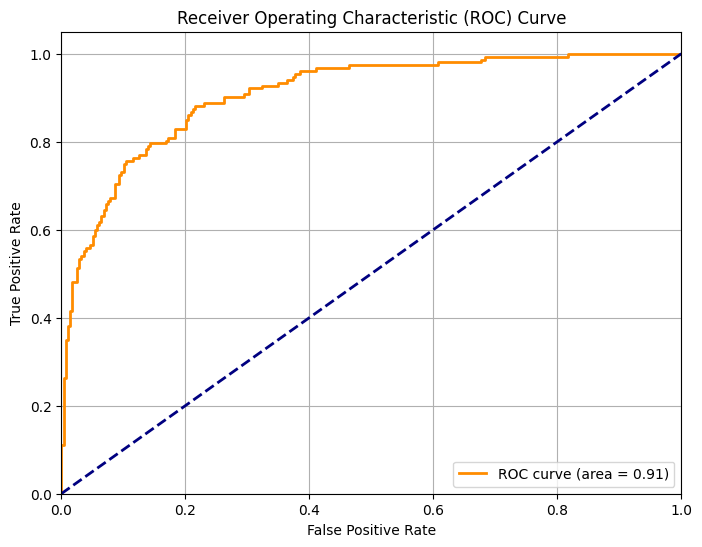

In [30]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns

best_model = rs_best.best_estimator_
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)

print("\nFinal Model Evaluation:")
print("Best Parameters:", rs_best.best_params_)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nF1 Score:", f1_score(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, best_model.predict_proba(X_test)[:, 1]))

# Confusion Matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Alzheimer\'s', 'Alzheimer\'s'],
            yticklabels=['No Alzheimer\'s', 'Alzheimer\'s'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# ROC Curve Plot
plt.figure(figsize=(8, 6))
y_proba = best_model.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)
plt.plot(fpr, tpr, color='darkorange', lw=2,
         label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid()

plt.show()

The confusion matrix shows a balanced detection of both classes, with relatively low false negatives, which is crucial in a medical diagnosis scenario

The ROC curve arches well above the diagonal indicating good classifier.

# Conclusions

### Observations

Logistic Regression with LDA and resampling (SMOTE or RandomOverSampler) worked best

Model generalizes well (no clear overfitting)

F1 scores are consistently high, suggesting good handling of class imbalance

### Suggestions for Improvement

Trying more complex models or neural nets for better performance.

Understanding what features drive predictions.

Adjusting classification threshold to prioritize minimizing false negatives.